## The Lab:


1. Pick something else on Craigslist besides used cars: Musical instruments, roommates, antiques, etc. Look at the search page and its source code. Record which fields/data you would like to gather, and what kinds of basic EDA you'd do with it.
2. Get your search results of interest using `requests` and extract data from them using `beautifulSoup`, using code similar to what's above.
3. Wrangle your data into a dataframe and do some basic descriptions and plots. Try to find some interesting relationships or stories to tell about your data.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bs4 import BeautifulSoup as soup # HTML parser
import requests # Page requests
import re # Regular expressions
import time # Time delays
import random # Random numbers

# want to look for jewelry for sale on craigslist
header = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) Gecko/20100101 Firefox/124.0'} 
url = 'https://charlottesville.craigslist.org/search/jwa#search=2~gallery~0'
raw = requests.get(url,headers=header) # Get page

types = ['necklace', 'watch', 'bracelet', 'ring', 'earring']


bsObj = soup(raw.content,'html.parser') # Parse the html
listings = bsObj.find_all(class_="cl-static-search-result") # Find all listings

In [13]:
data = [] # We'll save our listings in this object
for k in range( len(listings) ):
    title = listings[k].find('div',class_='title').get_text().lower()
    price = listings[k].find('div',class_='price').get_text()
    link = listings[k].find(href=True)['href']
    # Get types from the title string:
    words = title.split()
    hits = [word for word in words if word in types] # Find types in the title
    if len(hits) == 0:
        types = 'missing'
    else:
        types = hits[0]
    # Get years from title string:
    regex_search = re.search(r'20[0-9][0-9]|19[0-9][0-9]', title ) # Find year references
    if regex_search is None: # If no hits, record year as missing value
        year = np.nan 
    else: # If hits, record year as first match
        year = regex_search.group(0)
    #
    data.append({'title':title,'price':price,'year':year,'link':link,'types':types})

In [14]:
## Wrangle the data
df = pd.DataFrame.from_dict(data)
df['price'] = df['price'].str.replace('$','')
df['price'] = df['price'].str.replace(',','')
df['price'] = pd.to_numeric(df['price'],errors='coerce')
df['year'] = pd.to_numeric(df['year'],errors='coerce')
df['age'] = 2025-df['year']
print(df.shape)
df.to_csv('craigslist_cville_jewelry.csv')
df.head()

(31, 6)


,title,price,year,link,types,age
0,"> ladies ring - amethyst, diamonds & 10k gold,...",0,NaN,https://charlottesville.craigslist.org/jwl/d/c...,ring,NaN
1,vintage elgin ramona gold plated ladies watch ...,150,NaN,https://charlottesville.craigslist.org/jwl/d/c...,missing,NaN
2,vintage linda van der linde pink porcelain ear...,50,NaN,https://charlottesville.craigslist.org/jwl/d/c...,missing,NaN
3,silver rings,1,NaN,https://charlottesville.craigslist.org/jwl/d/g...,missing,NaN
4,2002 tj 4.0 wrangler drivetrain 36 k original...,2700,2002.0,https://charlottesville.craigslist.org/jwl/d/s...,missing,23.0


count       31.000000
mean       610.129032
std       2529.422302
min          0.000000
25%         17.500000
50%         50.000000
75%        135.000000
max      13995.000000
Name: price, dtype: float64


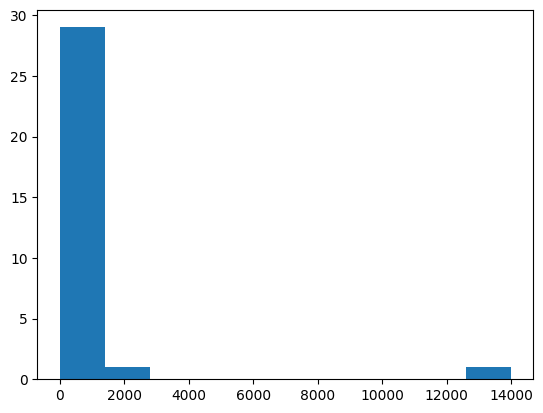

count     2.000000
mean     11.500000
std      16.263456
min       0.000000
25%       5.750000
50%      11.500000
75%      17.250000
max      23.000000
Name: age, dtype: float64


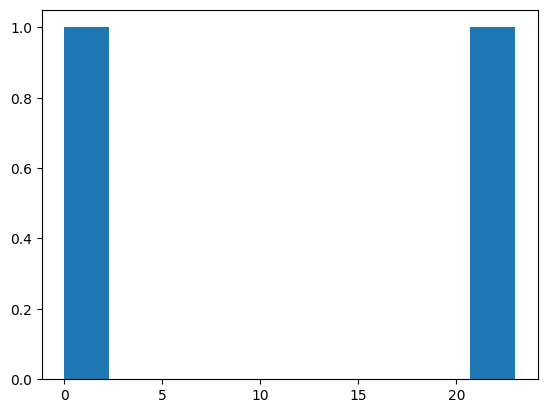

In [15]:
# EDA for price and age:
print(df['price'].describe())
df['price'].hist(grid=False)
plt.show()
print(df['age'].describe())
df['age'].hist(grid=False)
plt.show()

In [16]:
# Price by type:
df.loc[:,['price','types']].groupby('types').describe()

price                                                              
        count        mean          std    min    25%    50%    75%      max
types                                                                      
in        1.0  300.000000          NaN  300.0  300.0  300.0  300.0    300.0
missing  29.0  641.862069  2614.804523    1.0   20.0   50.0  125.0  13995.0
ring      1.0    0.000000          NaN    0.0    0.0    0.0    0.0      0.0

In [17]:
# Age by type:
df.loc[:,['age','types']].groupby('types').describe()

age                                               
        count  mean        std  min   25%   50%    75%   max
types                                                       
in        0.0   NaN        NaN  NaN   NaN   NaN    NaN   NaN
missing   2.0  11.5  16.263456  0.0  5.75  11.5  17.25  23.0
ring      0.0   NaN        NaN  NaN   NaN   NaN    NaN   NaN

In [18]:
df.loc[ df['types']=='watch',:]

,title,price,year,link,types,age


<Axes: xlabel='age', ylabel='price'>

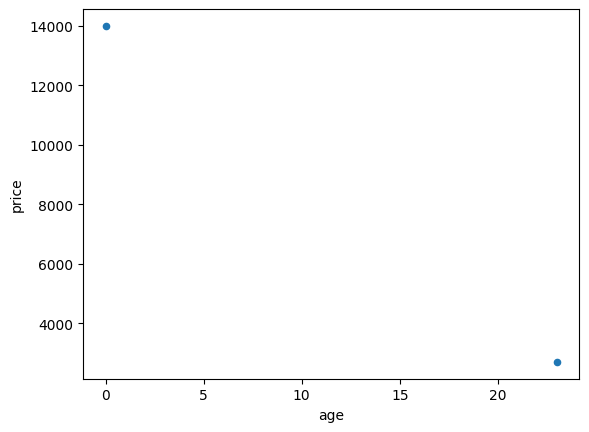

In [19]:
df.plot.scatter('age','price')

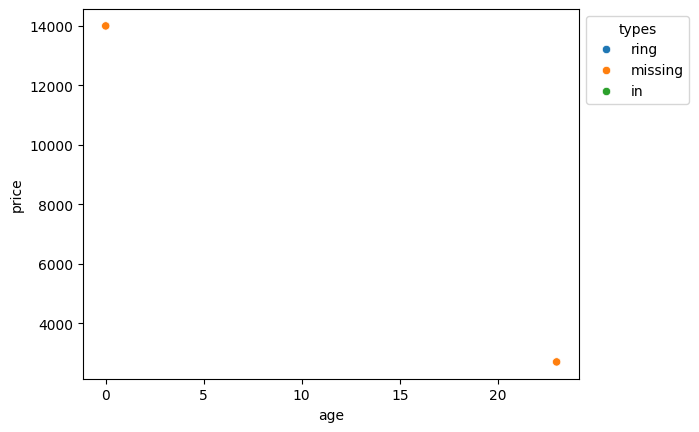

In [20]:
ax = sns.scatterplot(data=df, x='age', y='price',hue='types')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

c:\Users\elyse\Desktop\Elyse-Undan\UVA-26-SpringSem\FoundationsOfML\HW2\wrangling\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


           log_price  log_age
log_price   3.403475      NaN
log_age          NaN      NaN
           log_price  log_age
log_price        1.0      NaN
log_age          NaN      NaN


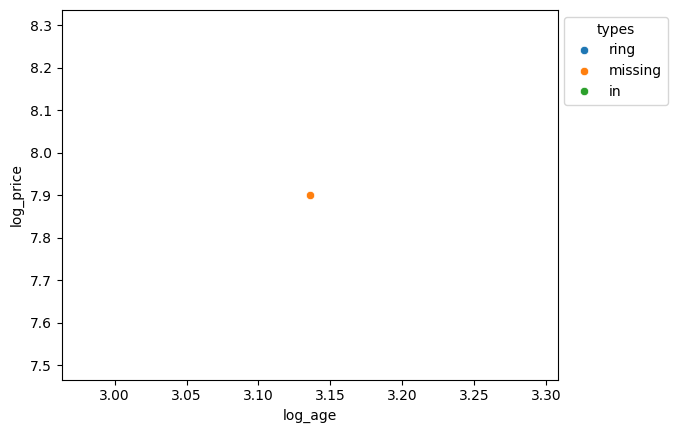

In [21]:
df['log_price'] = np.log(df['price'])
df['log_age'] = np.log(df['age'])

ax = sns.scatterplot(data=df, x='log_age', y='log_price',hue='types')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

print(df.loc[:,['log_price','log_age']].cov())
print(df.loc[:,['log_price','log_age']].corr())

c:\Users\elyse\Desktop\Elyse-Undan\UVA-26-SpringSem\FoundationsOfML\HW2\wrangling\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4597: RuntimeWarning: invalid value encountered in add
  lerp_interpolation = add(a, diff_b_a * t, out=... if out is None else out)


ValueError: cannot convert float NaN to integer

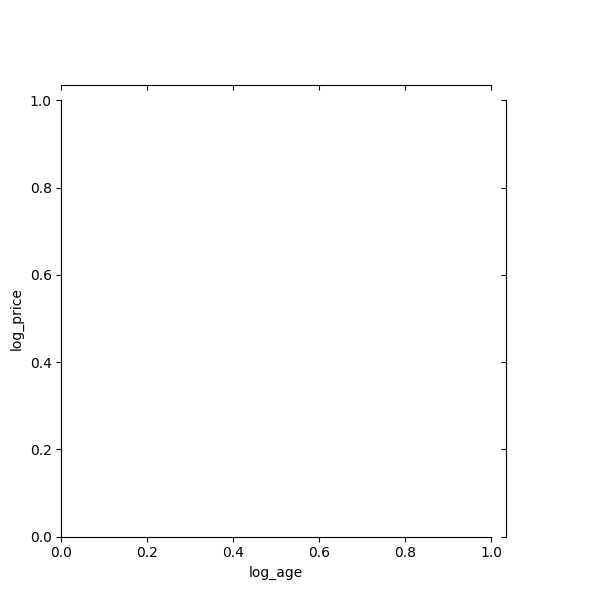

In [22]:
sns.jointplot(data=df, x='log_age', y='log_price',kind='hex')

In [ ]:
df.head()

In [ ]:
# links = df['link']
# data = []
# for link in links: # about 3 minutes
#     time.sleep(random.randint(1, 3))
#     raw = requests.get(link,headers=header) # Get page
#     bsObj = soup(raw.content,'html.parser') # Parse the html
#     #
#     try:
#         year_post = bsObj.find(class_='attr important').find(class_ = 'valu year').get_text()
#     except:
#         year_post = np.nan
#     #
#     try:
#         condition = bsObj.find(class_='attr condition').find(href=True).get_text()
#     except:
#         condition = 'missing'
#     #
#     try:
#         cylinders = bsObj.find(class_='attr auto_cylinders').find(class_ = 'valu').get_text()
#         cylinders = cylinders.replace('\n','')
#     except:
#         cylinders = 'missing'
#     #
#     try:
#         drivetrain = bsObj.find(class_='attr auto_drivetrain').find(href=True).get_text()
#     except:
#         drivetrain = 'missing'
#     #
#     try:
#         fuel = bsObj.find(class_='attr auto_fuel_type').find(href = True).get_text()
#     except:
#         fuel = 'missing'
#     #
#     try:
#         miles = bsObj.find(class_='attr auto_miles').find(class_ = 'valu').get_text()
#     except:
#         miles = np.nan
#     #
#     try:
#         color = bsObj.find(class_='attr auto_paint').find(href=True).get_text()
#     except:
#         color='missing'
#     #
#     try:
#         title = bsObj.find(class_='attr auto_title_status').find(href=True).get_text()
#     except:
#         title='missing'
#     #
#     try:
#         transmission = bsObj.find(class_='attr auto_transmission').find(href=True).get_text()
#     except:
#         transmission = 'missing'
#     #
#     try:
#         bodytype = bsObj.find(class_='attr auto_bodytype').find(href=True).get_text()
#     except:
#         bodytype = 'missing'
#     text = bsObj.find(id='postingbody').get_text()
#     text = text.replace('\n','')
#     text = text.replace('QR Code Link to This Post','')
#     record = {'title':title,
#               'year_post':year_post,
#               'condition':condition,
#               'cylinders':cylinders,
#               'drivetrain':drivetrain,
#               'fuel':fuel,
#               'miles':miles,
#               'color':color,
#               'title':'title',
#               'transmission':transmission,
#               'bodytype':bodytype,
#               'text':text,}
#     data.append(record)

In [ ]:
new_df = pd.DataFrame.from_dict(data)
new_df.head()

In [ ]:
new_df.shape

In [ ]:
df = pd.concat([df,new_df],axis=1) # combine data frames
df.head()

In [ ]:
df.dtypes

In [ ]:
# df['miles'] = df['miles'].str.replace(',','')
# df['miles'] = pd.to_numeric(df['miles'],errors='coerce')

# df['year_post'] = df['year_post'].str.replace(',','')
# df['year_post'] = pd.to_numeric(df['year_post'],errors='coerce')
# df.to_csv('craiglist_cville_cars_long.csv')

In [ ]:
ax = sns.scatterplot(data=df, x='age', y='miles',hue='type')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))